Calibrating the results of the tested methods according to the linear relationship using parameters fitted in *Compare_plots.ipynb*.

The code was written by Mária Pálfi (marika97@student.elte.hu).

In [1]:
# importing useful packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import seaborn as sns
sns.set_style('white') # set figure style
from pyrolite.plot.density import density
from matplotlib.lines import Line2D

In [2]:
# reading the file to pandas dataframe
check = pd.read_csv( '../check_sm.txt', delimiter = '\t', low_memory = False )
check.head()

,ID,2MASS,wiseX,type,ra,dec,K,K_err,W1,W1_err,...,log_sm,d_log_sm,fluxscale,log_gama_sm,log_sm_lambdar,d_log_sm_lambdar,fluxscale_lambdar,log_gama_sm_lambdar,sm,log_gama_sm_magphys
0,260,12125210+0117588,J121252.11+011758.9,G,183.217087,1.299673,7.953,0.015,8.868,NaN,...,10.67840,0.104434,1.077330,10.740281,10.67200,0.108565,1.076980,10.733740,26270000000,10.419460
1,1025,14463127+0116286,J144631.24+011629.2,G,221.630325,1.274620,10.528,0.048,10.926,NaN,...,11.08790,0.110348,1.165130,11.183806,11.08410,0.112150,1.255260,11.212366,126100000000,11.100715
2,1656,14441893+0002312,J144418.90+000230.8,G,221.078888,0.042021,11.229,0.071,11.679,NaN,...,10.69100,0.109208,1.254340,10.818947,10.68640,0.119500,0.984636,10.709208,33090000000,10.519697
3,1899,12024266+0157083,J120242.71+015707.2,G,180.677765,1.952326,11.402,0.075,12.060,NaN,...,10.44000,0.113381,0.875903,10.411988,10.41900,0.107483,1.071390,10.478480,28080000000,10.448397
4,2791,08360330+0119469,J083603.32+011947.2,G,129.013763,1.329719,12.066,0.081,12.225,0.023,...,9.83516,0.115833,1.112100,9.910836,9.84532,0.109942,1.118270,9.923399,3542000000,9.549249


In [3]:
# for the linear fitting
def linfit( x, a, b ):
    return a*x+b 

Extinction correction for 2MASS Kmag and calculating absolute magnitude

In [4]:
from __future__ import print_function
from astropy.coordinates import SkyCoord
from dustmaps.sfd import SFDQuery

# filter out galaxies which does not have a counterpart in the 2MASS
filt = check["k_m_ext"].notnull() == True
glade_2MASS = check[filt]

ra = glade_2MASS['ra']
dec = glade_2MASS['dec']

coords = SkyCoord(ra, dec, unit='deg', frame='icrs')
sfd = SFDQuery()
ebv = sfd(coords)

ext = 2.742 * ebv 
glade_2MASS['ext'] = ext

abs_m_Ks_E = glade_2MASS.k_m_ext - 5*np.log10(glade_2MASS.dL) - 25 - 0.11 * ext 

Function for the calibration:

In [5]:
def calibrating( gama, sample, a, b, my_sm, name, magname ):
    fig = plt.figure( figsize = (20, 12), dpi = 100 )
    ax = fig.add_subplot(1, 1, 1)
    plt.xticks( fontsize = 35 )
    plt.yticks( fontsize = 35 )
    plt.xlim( [9.1, 12] )
    plt.ylim( [9.1, 12.7] )
    plt.tick_params( length=10, direction = 'inout', pad = 5 )
    ax.xaxis.get_offset_text().set_visible(False)
    ax.yaxis.get_offset_text().set_visible(False)
    pd.DataFrame( { "gama": gama,
                    "sample" : sample } ).pyroplot.density( ax=ax, contours=[0.95], linewidths=5, zorder = 10, colors = ['purple'],
                                                            label_contours=False )
    x = np.linspace( 9, 12, 100 )
    plt.plot(x, x, c = 'k', zorder = 10)
    pd.DataFrame( { "gama": gama,
                    "sample" : (sample-b)/a} ).pyroplot.density( ax=ax, contours=[0.95], linewidths=5, linestyles = '-.', zorder = 10, 
                                                                 colors = ['green'], label_contours=False )
    pd.DataFrame( { "gama": gama,
                    "sample" : my_sm } ).pyroplot.density( ax=ax, contours=[0.95], linewidths=5, linestyles = '--', label_contours=False,
                                                           zorder = 10, colors = ['brown'] )
    

    custom_lines = [Line2D([0], [0], color='purple', lw=4, label = name + ' uncalibrated'),
                    Line2D([0], [0], color='green', lw=4, ls ='-.', label = name + ' calibrated'),
                    Line2D([0], [0], color='brown', lw=4, ls ='--',  label = 'our fit with ' + magname)]

    plt.legend( facecolor = 'white', frameon = True, bbox_to_anchor=(0, 1), fontsize = 30, handles = custom_lines )
    plt.xlabel( '$\log_{10}(M_{GAMA}$ [M$_{\odot}$])', fontsize = 40 )
    plt.ylabel( '$\log_{10}(M_{estimated}$ [M$_{\odot}$])', fontsize = 40 )
    plt.grid()
    plt.savefig( '../shifted_' + name + '.pdf', format = 'pdf' );

Our fit for 2MASS Kmag:

y = ( -0.38569574123002454 $\pm$ 0.003016198762897389 )*x +  1.1941302183076477 $\pm$ 0.07517131031604168


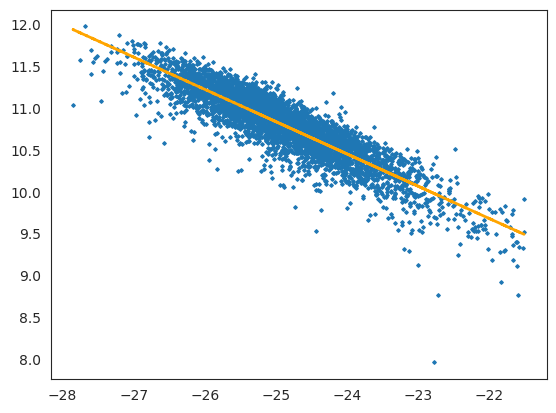

In [6]:
plt.scatter( abs_m_Ks_E, check.log_gama_sm_magphys, s = 3 )
popt, pcov = curve_fit( linfit, abs_m_Ks_E, check.log_gama_sm_magphys, p0 = [0.8, 2] )
print( 'y = (', popt[0], '$\pm$', np.sqrt(pcov[0,0]), ')*x + ', popt[1], '$\pm$', np.sqrt(pcov[1,1]) )

plt.plot( abs_m_Ks_E, popt[0] * abs_m_Ks_E + popt[1], lw = 2, ls = '--',
         c = 'orange' )

my_sm_K = popt[0] * abs_m_Ks_E + popt[1];

Calibration plot for Cappellari's method:

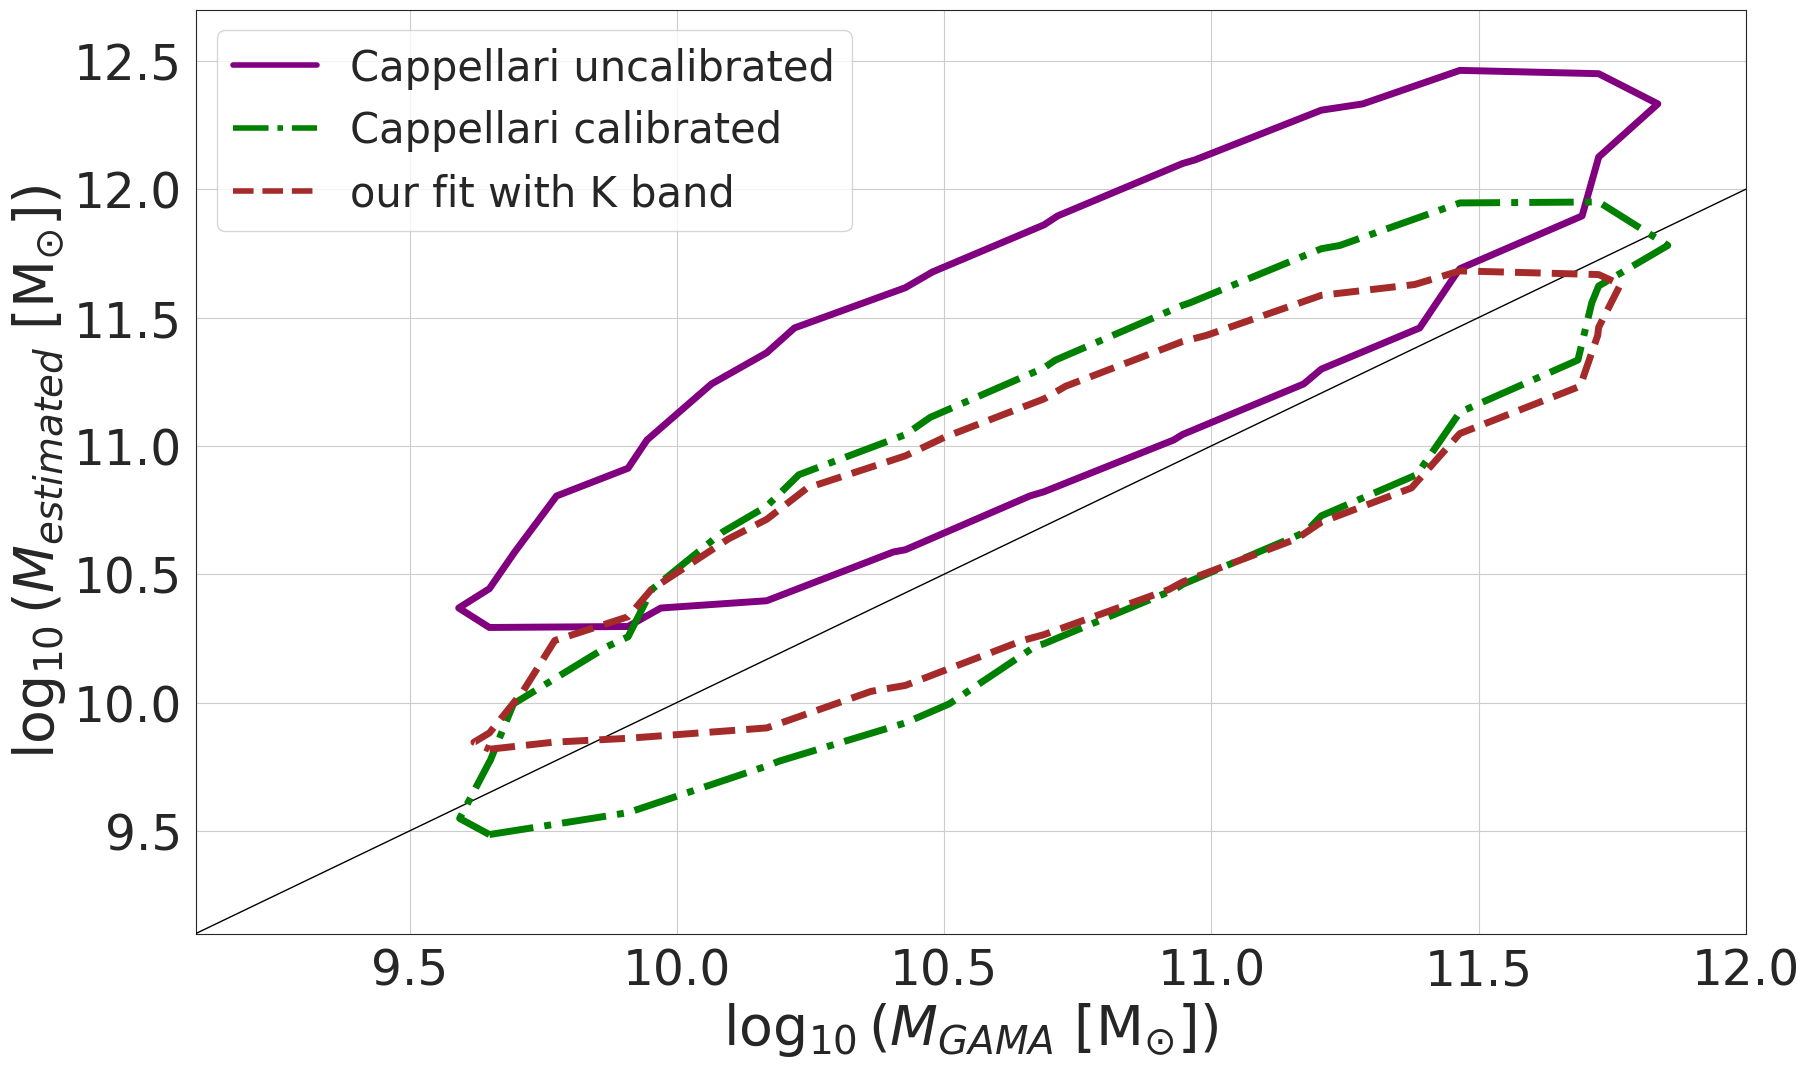

In [7]:
calibrating( gama = check.log_gama_sm_magphys, sample = np.log10(check.SMass_Cappellari), 
             b = 1.41, a = 0.923, my_sm = my_sm_K, name = 'Cappellari', magname = 'K band' )

Calculating W1 and W2 absolute magnitudes:

In [8]:
# absolute magnitude in the W1 band without K correction:
M1_wKc = check.W1 + 5 - 5 * np.log10( check.dL*1e6 )
print( 'absolute magnitude in the W1 band without K correction:' )
print( M1_wKc.iloc[0:5] )

# K corrected absolute W1 magnitudes:
M1 = M1_wKc + 2.5854 * check.z 
print( '\nK corrected absolute W1 magnitudes:' )
print( M1.iloc[0:5] )

# K correction for W1 magnitudes according to Kettlety:
M1_Kettlety = M1_wKc + 7.1 * np.log10(1+check.z) 
print( '\nK corrected absolute W1 magnitudes according to Kettlety:' )
print( M1_Kettlety.iloc[0:5] )


# absolute magnitude in the W2 band without K correction:
M2_wKc = check.W2 + 5 - 5 * np.log10( check.dL*1e6 )
print( '\nabsolute magnitude in the W2 band without K correction:' )
print( M2_wKc.iloc[0:5] )

# K corrected absolute W2 magnitudes:
M2 = M2_wKc + 2.9358 * check.z 
print( '\nK corrected absolute W2 magnitudes:' )
print( M2.iloc[0:5] )

absolute magnitude in the W1 band without K correction:
0   -21.795442
1   -24.483997
2   -23.923173
3   -22.449355
4   -22.856001
dtype: float64

K corrected absolute W1 magnitudes:
0   -21.785989
1   -24.412318
2   -23.847850
3   -22.400787
4   -22.798201
dtype: float64

K corrected absolute W1 magnitudes according to Kettlety:
0   -21.784189
1   -24.399672
2   -23.834623
3   -22.391967
4   -22.787825
dtype: float64

absolute magnitude in the W2 band without K correction:
0   -21.758442
1   -24.393997
2   -23.872173
3   -22.347355
4   -22.838001
dtype: float64

K corrected absolute W2 magnitudes:
0   -21.747708
1   -24.312603
2   -23.786642
3   -22.292204
4   -22.772368
dtype: float64


Our fit with Kettlety's functional form:

In [9]:
M_sun = 3.24
print( 'W1 luminosity:' )
L_W1_Kettlety = 10**( -0.4 * ( M1_Kettlety - M_sun ) )
print( L_W1_Kettlety.iloc[0:5] )

W1 luminosity:
0    1.022529e+10
1    1.137284e+11
2    6.758482e+10
3    1.789727e+10
4    2.577093e+10
dtype: float64


In [10]:
def linfit_Kettlety( x, a ):
    return a*x

In [11]:
popt, pcov = curve_fit( linfit_Kettlety, L_W1_Kettlety, 10**check.log_gama_sm_magphys, p0 = [0.8] )
print( 'y = (', popt[0], '$\pm$', np.sqrt(pcov[0,0]), ')*x' )

my_sm_W1 = popt[0] * L_W1_Kettlety

y = ( 0.5969797485382361 $\pm$ 0.0045624643195999815 )*x


Calibration plot for Kettlety's method:

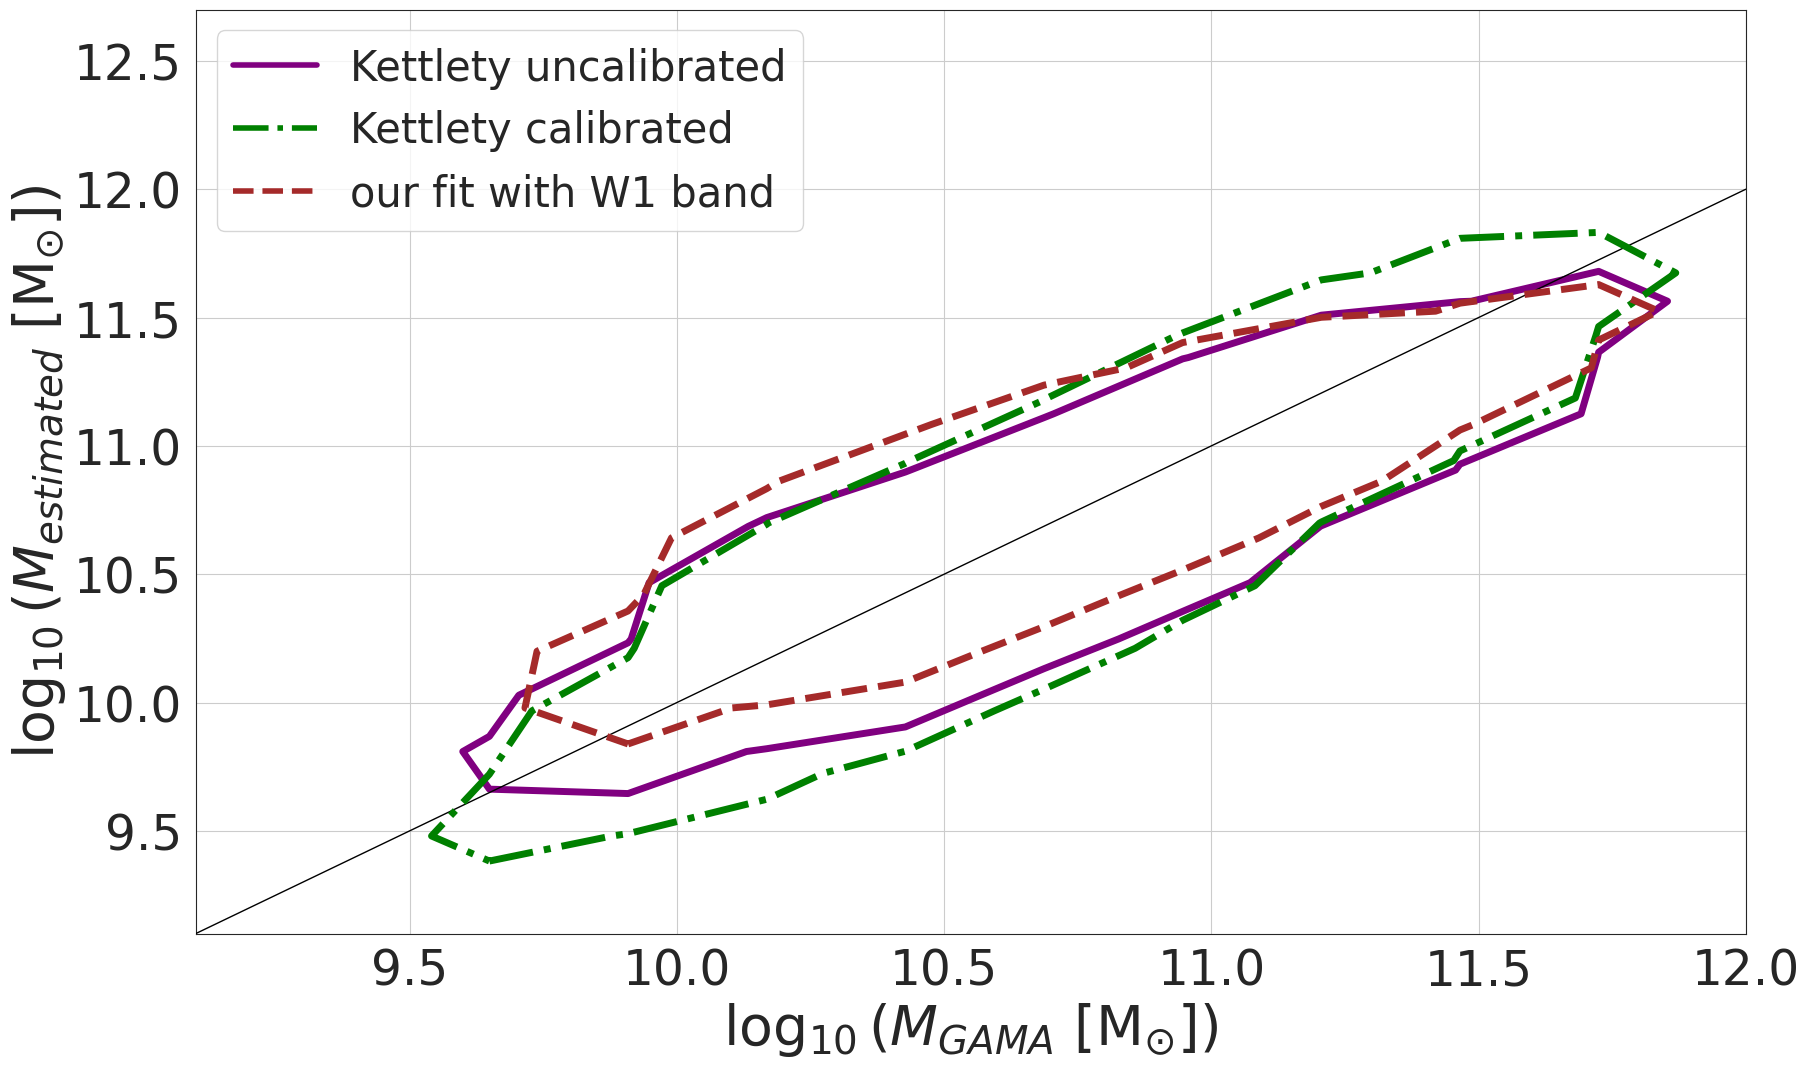

In [12]:
calibrating( gama = check.log_gama_sm_magphys, sample = np.log10(check.SMass_Kettlety), 
             b = 1.71, a = 0.839, my_sm = np.log10(my_sm_W1), name = 'Kettlety', magname = 'W1 band' )

Our fit with Jarrett's and Cluver's functional form:

In [13]:
M_sun = 3.24

L_W1 = 10**( -0.4 * ( M1 - M_sun ) )
L_W1.iloc[0:5]

0    1.024226e+10
1    1.150607e+11
2    6.841324e+10
3    1.804325e+10
4    2.601840e+10
dtype: float64

In [14]:
def linfit_WISE( color, a, b ):
    return (a*(color)+b)

In [15]:
popt, pcov = curve_fit( linfit_WISE, (M1-M2), np.log10(10**check.log_gama_sm_magphys/L_W1), p0 = [0.8, 0.2] )
print( 'y = (', popt[0], '$\pm$', np.sqrt(pcov[0,0]), ')*x + ', popt[1], '$\pm$', np.sqrt(pcov[1,1]) )

my_sm_WISE = (10**(popt[0] * (M1-M2) + popt[1]))*L_W1

y = ( -0.693570305890503 $\pm$ 0.021843226171824735 )*x +  -0.1659116263084079 $\pm$ 0.004078496664920928


Calibration plot for Cluver's method:

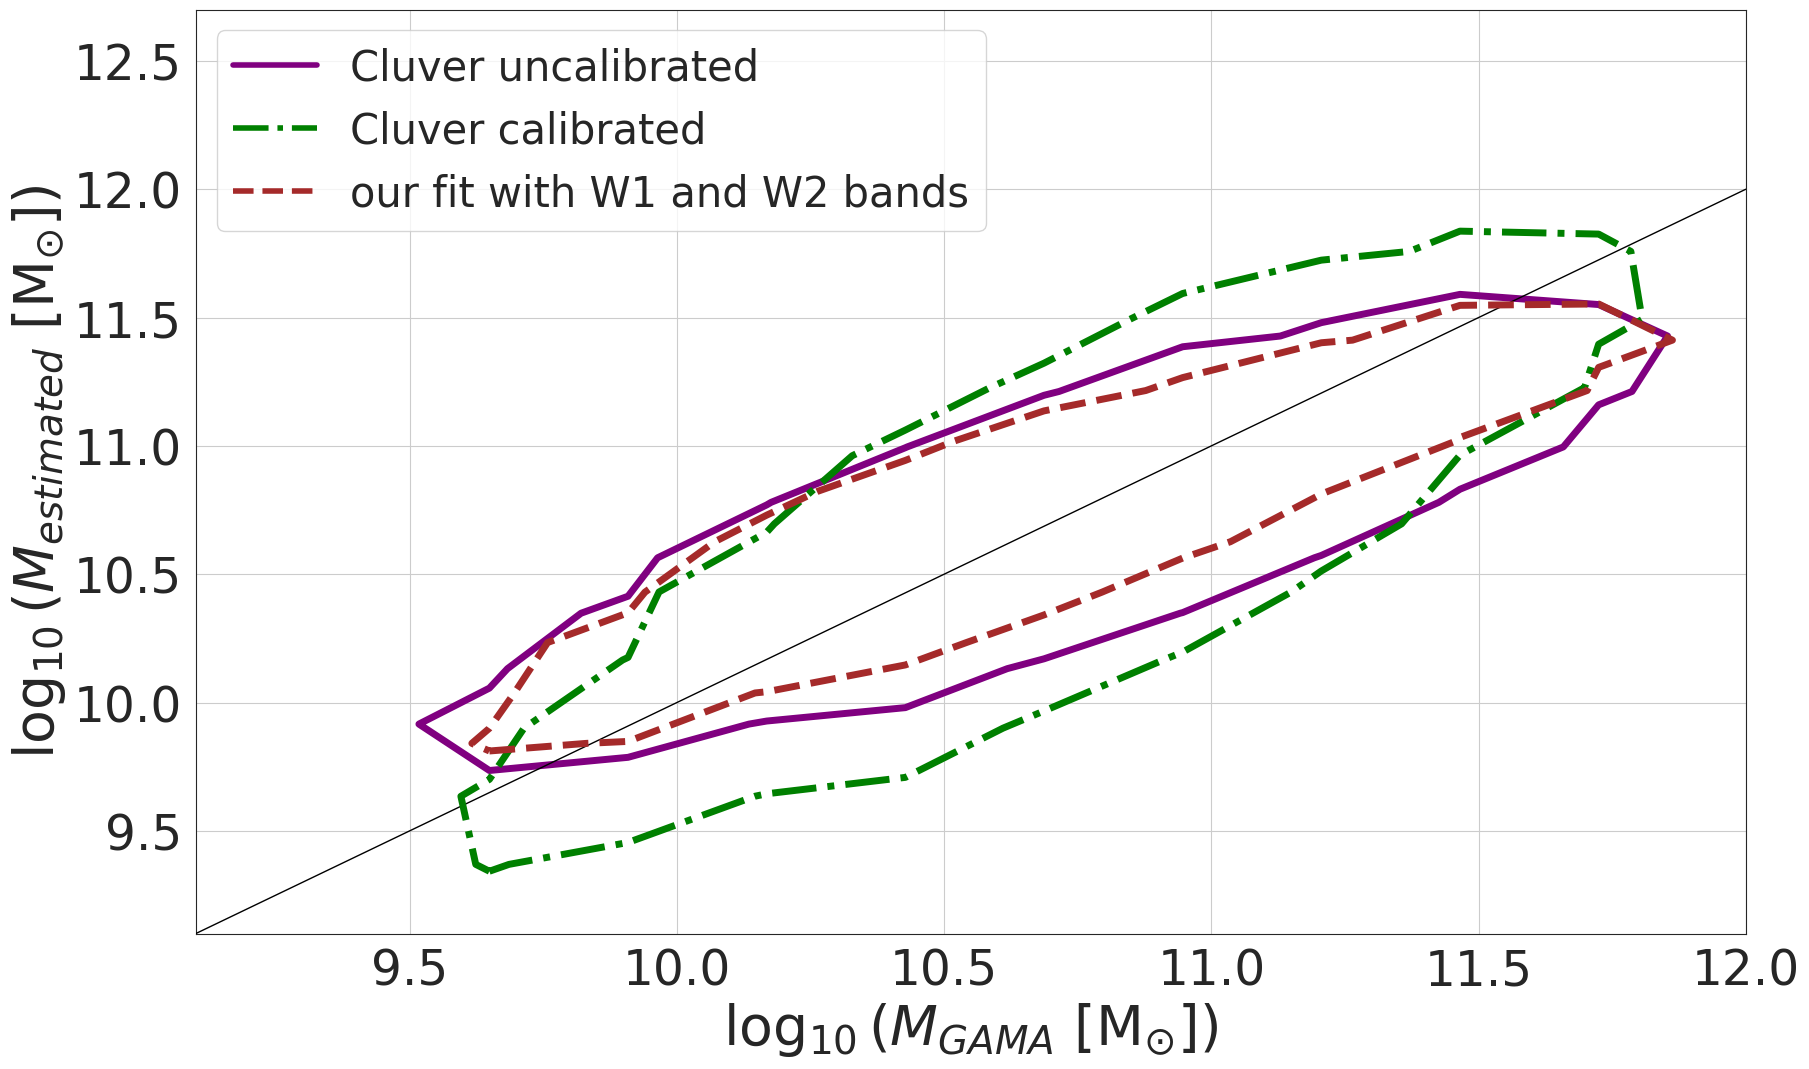

In [16]:
calibrating( gama = check.log_gama_sm_magphys, sample = np.log10(check.SMass_Cluver), 
             b = 3.10, a = 0.713, my_sm = np.log10(my_sm_WISE), name = 'Cluver', magname = 'W1 and W2 bands' )

Calibration plot for Cappellari's method:

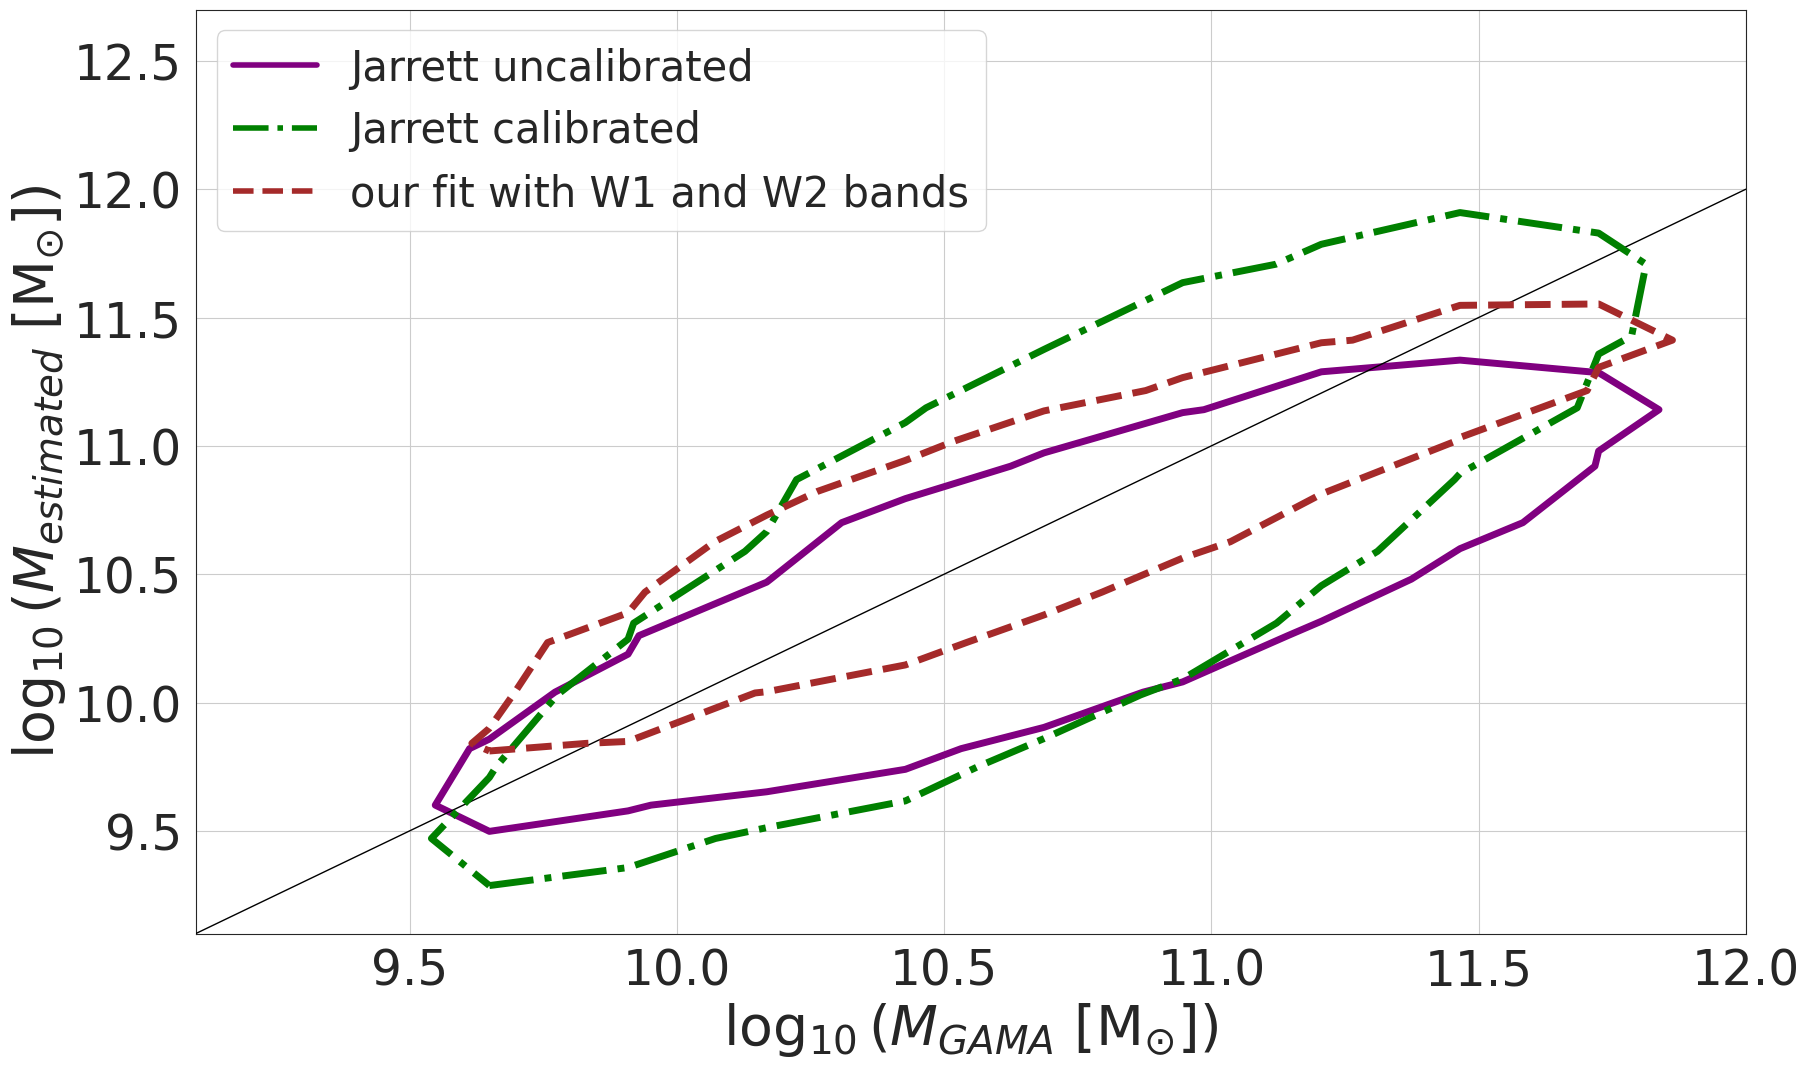

In [17]:
calibrating( gama = check.log_gama_sm_magphys, sample = np.log10(check.SMass_Jarrett), 
             b = 3.11, a = 0.691, my_sm = np.log10(my_sm_WISE), name = 'Jarrett', magname = 'W1 and W2 bands' )